# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [77]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

from astropy.time import Time
import astropy.units as u
from datetime import datetime

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [78]:
import numpy as np

filepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/20260217_143556_B0531+21.npz"

data = np.load(filepath, allow_pickle=True)

print(data.files)   # shows what's inside the npz
print(data['times'])

['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
[61088.6096061  61088.61180509 61088.61412005 61088.61643463
 61088.6187496  61088.62106456 61088.62337914 61088.62569411
 61088.62800907 61088.63032404 61088.63263901 61088.63491518
 61088.63726816 61088.63958312 61088.64188477 61088.64421306
 61088.64652724 61088.64884221 61088.65208348 61088.65347214
 61088.65578672 61088.65810169 61088.66041626 61088.66273162
 61088.6650458  61088.66736077 61088.66961775 61088.67199031
 61088.67430528 61088.67658146 61088.67910841 61088.68124979
 61088.68356437 61088.68587934 61088.68819391 61088.69050888]


In [79]:

import os
import numpy as np

basepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs"

npzfile  = os.path.join(basepath, "20260217_143556_B0531+21.npz")
baryfile = os.path.join(basepath, "2026_ssb.txt")

# Load barycentre file (text)
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile, unpack=True)

# Load pulsar observation (binary npz)
obs = np.load(npzfile, allow_pickle=True)

print("Loaded npz keys:", obs.files)
print("source_name:", obs["source_name"])
print("approx_period:", obs["approx_period"])
print("data shape:", obs["data"].shape)

print("Using baryfile:", baryfile)

Loaded npz keys: ['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
source_name: B0531+21
approx_period: 0.03385139
data shape: (36, 40, 1024)
Using baryfile: /Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/2026_ssb.txt


## Interpolation
The Earth-barycentre vector is only given once per day (at 0 UT) in your input file. Therefore you will need to [interpolate](https://en.wikipedia.org/wiki/Interpolation) to get the vector at the time of each of your ToAs.

The below is an example code showing interpolation of a simple sinusoid function. Make sure you understand what this code is doing, then replace it with a function to interpolate your x, y and z positions at the times of your ToAs.

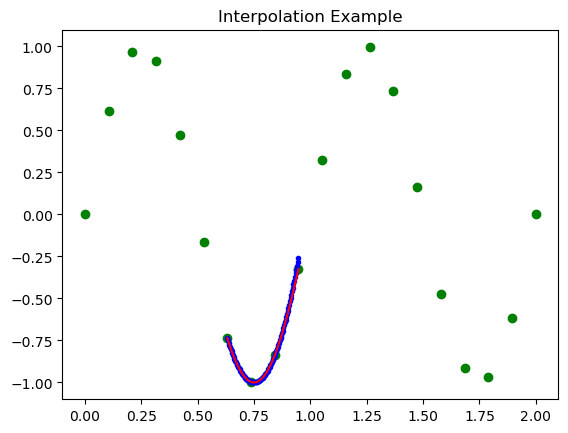

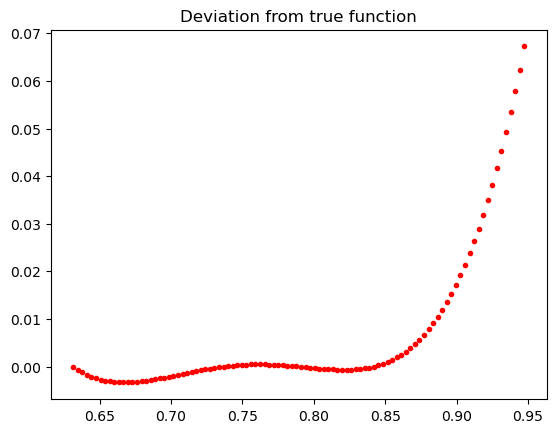

In [80]:
# Interpolation example, interpolating part of a sine function.

# This is the X and Y data points of the sine function
x = np.linspace(start=0,stop=2,num=20)
y = np.sin(2*pi*x)

# We will interpolate using
start_point = 6
interp_number=3

interp_function = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                       y[start_point:start_point+interp_number])

x2 = np.linspace(x[start_point],x[start_point+interp_number],100)
y2 = interp_function(x2)

y3 = np.sin(2*pi*x2)

plt.plot(x,y,'o',color='green')
plt.plot(x2,y2,'.',color='blue')
plt.plot(x2,y3,'-',color='red')
plt.ylim(-1.1,1.1)
plt.title("Interpolation Example")
plt.figure()
plt.plot(x2,y2-y3,'.',color='red')
plt.title("Deviation from true function")
plt.show()


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``
 

In [129]:
from astropy.coordinates import EarthLocation

# Insert the position of the crab pulsar here!
pulsarpos = coord.SkyCoord(ra="01:23:45.6", dec="12:34:56.7", unit=(u.hourangle,u.deg))

# Jodrell Bank 42-ft telescope approximate location
JBpos = EarthLocation(
    lat=53.2359065 * u.deg,
    lon=-2.3064801 * u.deg,
    height=80*u.m)




In [130]:
import numpy as np
from astropy.time import Time
import astropy.units as u

# Path to your saved ToA file
toa_file = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/B0531+21_toas.txt"

# Load file (ignore lines starting with #)
data = np.loadtxt(toa_file)

# First column = MJD
toa_mjd = data[:, 0]

# Second column = uncertainty (seconds)
toa_err_sec = data[:, 1]

print("Loaded", len(toa_mjd), "ToAs")
print("First ToA:", toa_mjd[0], "±", toa_err_sec[0], "sec")

# Create astropy Time object (topocentric times at telescope)
times = Time(toa_mjd, format="mjd", scale="utc", location=JBpos)

print("Time object created successfully.")

Loaded 36 ToAs
First ToA: 61088.609606118735 ± 5.978472e-05 sec
Time object created successfully.


In [131]:
times = Time(toa_mjd, format="mjd", scale="utc", location=JBpos)


# Start of observation
start_time = Time("2026-02-17 14:36:00", format="iso", scale="utc")

integration_time = 7196.999708 * u.s
mid_time = start_time + integration_time / 2




bary_datetimes = [datetime(int(y), int(m), int(d), 0, 0, 0) for y, m, d in zip(year, month, day)]
bary_mjd = Time(bary_datetimes, scale="utc").mjd



/Users/alismk/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


In [132]:
print("toa_mjd range:", toa_mjd.min(), "to", toa_mjd.max())
print("bary_mjd range:", bary_mjd.min(), "to", bary_mjd.max())


toa_mjd range: 61088.609606118735 to 61088.69050889372
bary_mjd range: 61041.0 to 61405.0


In [133]:

# To compute the angle between the pulsar and the earth we can use astropy to tell us the elevation angle to the pulsar.
# First Transform the coordinate system to an Alt-Az system. This needs the location of the telescope and the times
# of the observation.
# altaz = pulsarpos.transform_to(coord.AltAz(obstime=times,location=lovellpos))

altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=JBpos))
elevation = altaz.alt.to(u.rad).value
# earth_delay = ...

R_earth = 6371000.0  # m (good enough)
c = 299792458.0      # m/s

earth_delay_sec = (R_earth * np.sin(elevation)) / c
earth_delay_days = earth_delay_sec / 86400.0
toa_geo_mjd = toa_mjd - earth_delay_days

print("Earth-telescope delay range (sec):",
      earth_delay_sec.min(), "to", earth_delay_sec.max())

Earth-telescope delay range (sec): 0.01564191985761016 to 0.016155517680589215


## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.


In [134]:
x_interp = np.interp(toa_mjd, bary_mjd, xpos)
y_interp = np.interp(toa_mjd, bary_mjd, ypos)
z_interp = np.interp(toa_mjd, bary_mjd, zpos)

print("Δx over obs:", x_interp.max() - x_interp.min())
print("Δy over obs:", y_interp.max() - y_interp.min())
print("Δz over obs:", z_interp.max() - z_interp.min())

Δx over obs: 0.0007502798761890306
Δy over obs: 0.0010936447639912639
Δz over obs: 0.0004741408256499213


In [135]:
pulsarpos = coord.SkyCoord(ra="01:23:45.6", dec="12:34:56.7", unit=(u.hourangle,u.deg))

# psr_x = ...
# psr_y = ...
# psr_z = ...
# Unit vector toward pulsar
psr_x = pulsarpos.cartesian.x.value
psr_y = pulsarpos.cartesian.y.value
psr_z = pulsarpos.cartesian.z.value
# roemer_delay = ...

# Dot product r · n
c = 299792458.0
roemer_delay_sec = (x_interp * psr_x + y_interp * psr_y + z_interp * psr_z) / c

roemer_delay_days = roemer_delay_sec / 86400.0

toa_bary_mjd = toa_geo_mjd + roemer_delay_days
AU_m = 1.495978707e11
c = 299792458.0
roemer_delay_sec = (x_interp*psr_x + y_interp*psr_y + z_interp*psr_z) * (AU_m / c)

In [136]:
print("Roemer delay range (sec):",
      roemer_delay_sec.min(), "to", roemer_delay_sec.max())

Roemer delay range (sec): -281.94908805065006 to -281.3659219530945


In [137]:
print("total correction: ", toa_bary_mjd.min(),'to',toa_bary_mjd.max())
print("the difference: ", toa_bary_mjd.max()-toa_bary_mjd.min())

total correction:  61088.609605937694 to 61088.69050871023
the difference:  0.0809027725335909


## Residuals from a fixed period model



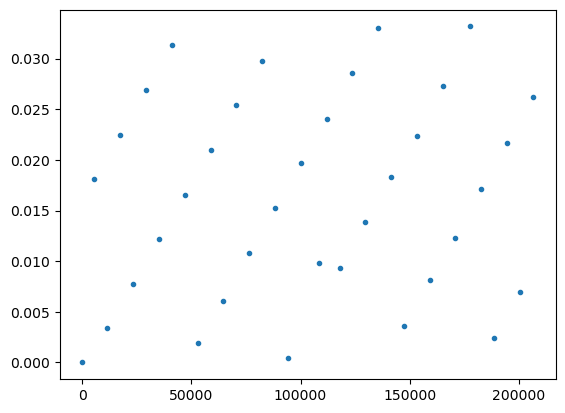

In [138]:
# The data file includes a sutiable 'guess period' as described in the lab script.
# You can either load the data file or get it from the 'Make Time of Arrivals' notebook.
period_guess = float(obs["approx_period"])

t_sec = (toa_mjd - toa_mjd[0]) * 86400

N = (t_sec / period_guess).astype(int)
# residual = 

residual_sec = t_sec - N * period_guess

plt.plot(N, residual_sec, ".")
plt.show()
# Do fitting (try the polyfit routine in numpy)

In [139]:
print(obs['approx_period'])
print(t_sec)

0.03385139
[   0.          189.9920726   390.00526113  589.98450232  789.99767262
  990.01083537 1189.99012748 1390.00330092 1590.01635555 1790.02954094
 1990.04268295 2186.70429792 2390.00126591 2590.01450913 2788.876578
 2990.04079315 3189.98622091 3389.99946287 3670.07594614 3790.02570666
 3990.00500694 4190.01823508 4389.99756114 4590.04453858 4789.98997388
 4990.00315361 5185.00589796 5389.99575495 5590.00890891 5786.6704673
 6004.99895392 6190.01463151 6389.99395003 6590.0071945  6789.9864885
 6989.99975875]


In [140]:
print(residual_sec)

[0.         0.01807192 0.00339694 0.0224774  0.00778419 0.02693482
 0.01221481 0.03137613 0.01656725 0.00188913 0.02101902 0.00605809
 0.02542913 0.01080884 0.02981285 0.01521723 0.00048426 0.0197141
 0.00979651 0.02408226 0.00937042 0.02858644 0.01390038 0.03301431
 0.01828888 0.0036051  0.02234305 0.0081822  0.02732404 0.01230653
 0.03317904 0.01715889 0.00246529 0.02169764 0.00697952 0.02623765]


In [141]:
print(N)

[     0   5612  11521  17428  23337  29245  35153  41061  46970  52879
  58787  64597  70602  76511  82385  88328  94235 100143 108417 111960
 117868 123776 129684 135593 141500 147409 153169 159225 165133 170943
 177392 182858 188766 194674 200582 206490]


In [ ]:
q